# 4-Model Macro Metrics Comparison

This notebook reads `training_outputs/seed_metrics.csv` for MobileNetV2, MobileNetV3Small, and ResNet50, then manually injects EfficientNetB0 macro metrics using your provided values.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_path = Path('training_outputs/seed_metrics.csv')
df = pd.read_csv(csv_path)

backbones = ['MobileNetV2', 'MobileNetV3Small', 'ResNet50']
metrics = ['macro_precision', 'macro_recall', 'macro_f1']

summary = (
    df[df['backbone'].isin(backbones)]
    .groupby('backbone', as_index=False)[metrics]
    .mean()
)

manual_efficientnetb0 = pd.DataFrame([
    {
        'backbone': 'EfficientNetB0',
        'macro_precision': 0.42,
        'macro_recall': 0.60,
        'macro_f1': 0.49,
    }
])

comparison_df = pd.concat([summary, manual_efficientnetb0], ignore_index=True)

order = ['MobileNetV2', 'MobileNetV3Small', 'ResNet50', 'EfficientNetB0']
comparison_df['backbone'] = pd.Categorical(comparison_df['backbone'], categories=order, ordered=True)
comparison_df = comparison_df.sort_values('backbone').reset_index(drop=True)

comparison_df


,backbone,macro_precision,macro_recall,macro_f1
0,MobileNetV2,0.107904,0.333333,0.163032
1,MobileNetV3Small,0.501314,0.552047,0.487286
2,ResNet50,0.258664,0.412592,0.308539
3,EfficientNetB0,0.420000,0.600000,0.490000


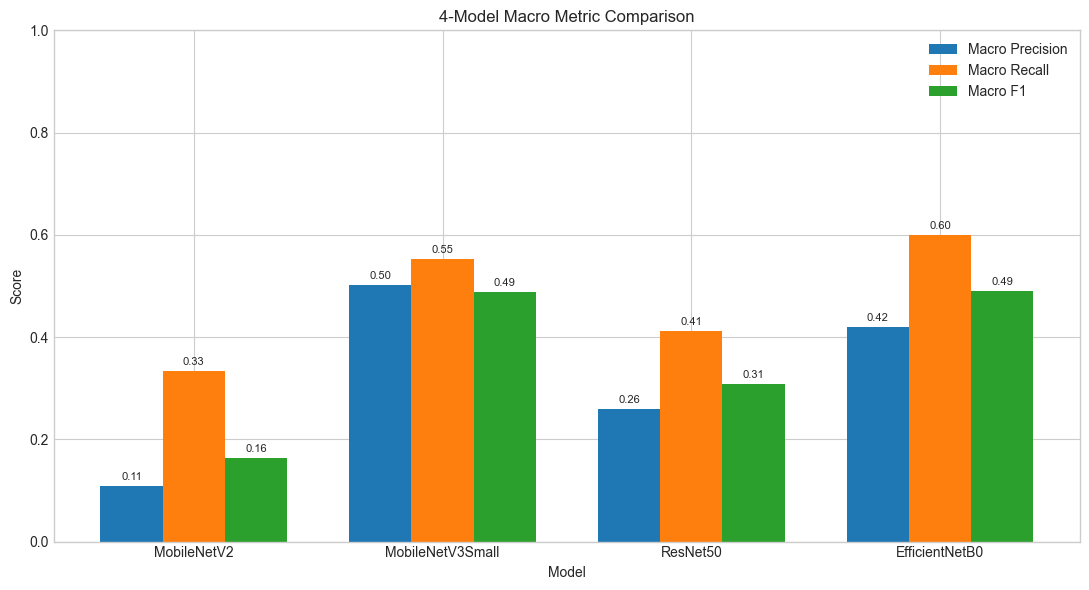

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
x = np.arange(len(comparison_df['backbone']))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width, comparison_df['macro_precision'], width, label='Macro Precision')
ax.bar(x, comparison_df['macro_recall'], width, label='Macro Recall')
ax.bar(x + width, comparison_df['macro_f1'], width, label='Macro F1')

ax.set_title('4-Model Macro Metric Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['backbone'])
ax.set_ylim(0, 1)
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()


,backbone,h5_size_mb,tflite_size_mb,inference_mean_ms_per_image,inference_std_ms_per_image
0,MobileNetV2,23.058029,9.086102,89.996401,4.633514
1,MobileNetV3Small,9.857300,3.860420,75.253891,17.853458
2,ResNet50,185.424545,90.620052,103.326958,16.784334
3,EfficientNetB0,0.005859,NaN,NaN,NaN


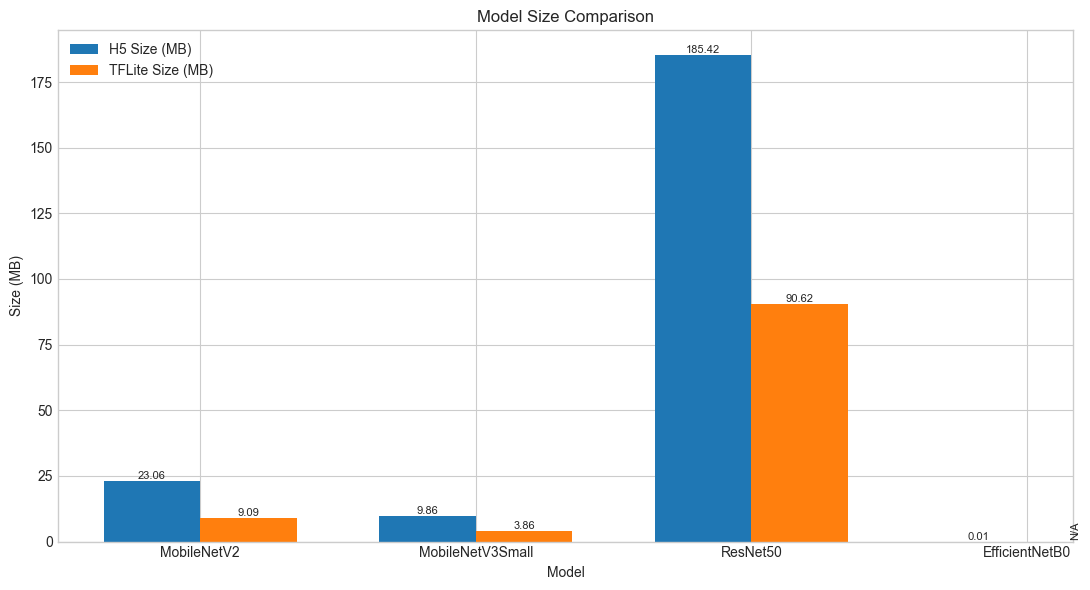

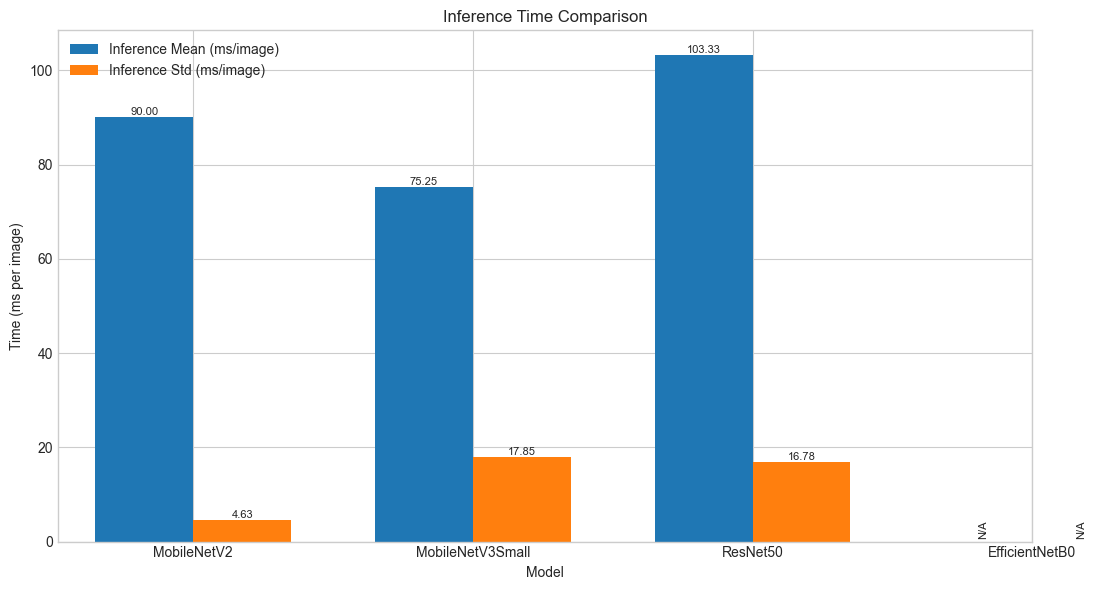

In [5]:
# Size and inference comparison charts
size_speed_metrics = ['h5_size_mb', 'tflite_size_mb', 'inference_mean_ms_per_image', 'inference_std_ms_per_image']
size_speed_df = (
    df[df['backbone'].isin(order)]
    .groupby('backbone', as_index=False)[size_speed_metrics]
    .mean()
)
size_speed_df['backbone'] = pd.Categorical(size_speed_df['backbone'], categories=order, ordered=True)
size_speed_df = size_speed_df.sort_values('backbone').reset_index(drop=True)
display(size_speed_df)

# Chart 1: h5_size_mb vs tflite_size_mb
x = np.arange(len(size_speed_df['backbone']))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
bars_h5 = ax.bar(x - width/2, size_speed_df['h5_size_mb'], width, label='H5 Size (MB)')
bars_tflite = ax.bar(x + width/2, size_speed_df['tflite_size_mb'], width, label='TFLite Size (MB)')
ax.set_title('Model Size Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Size (MB)')
ax.set_xticks(x)
ax.set_xticklabels(size_speed_df['backbone'])
ax.legend()
for bars in [bars_h5, bars_tflite]:
    for rect in bars:
        h = rect.get_height()
        if np.isnan(h):
            ax.text(rect.get_x() + rect.get_width()/2, 0.5, 'N/A', ha='center', va='bottom', fontsize=8, rotation=90)
        else:
            ax.text(rect.get_x() + rect.get_width()/2, h, f'{h:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# Chart 2: inference_mean_ms_per_image vs inference_std_ms_per_image
x = np.arange(len(size_speed_df['backbone']))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
bars_mean = ax.bar(x - width/2, size_speed_df['inference_mean_ms_per_image'], width, label='Inference Mean (ms/image)')
bars_std = ax.bar(x + width/2, size_speed_df['inference_std_ms_per_image'], width, label='Inference Std (ms/image)')
ax.set_title('Inference Time Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Time (ms per image)')
ax.set_xticks(x)
ax.set_xticklabels(size_speed_df['backbone'])
ax.legend()
for bars in [bars_mean, bars_std]:
    for rect in bars:
        h = rect.get_height()
        if np.isnan(h):
            ax.text(rect.get_x() + rect.get_width()/2, 0.5, 'N/A', ha='center', va='bottom', fontsize=8, rotation=90)
        else:
            ax.text(rect.get_x() + rect.get_width()/2, h, f'{h:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
